In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

In [42]:
train = np.load(f"data/train.npy")
PSM_resample_sample = np.load(f"samples/PSMDiff2048.npy")
train.shape, PSM_resample_sample.shape

((3914, 3033), (2048, 3033))

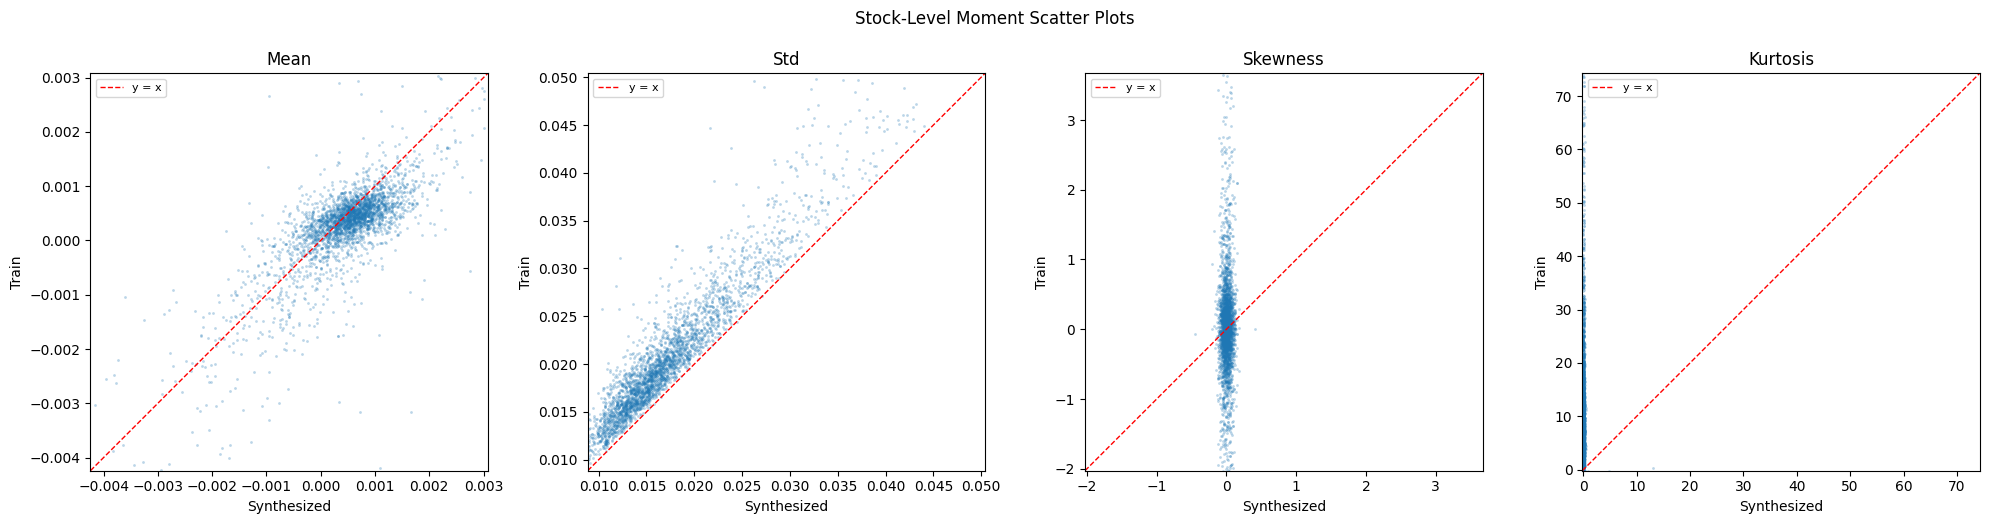

In [43]:
# Compute per-stock moments along time axis (NaN-aware)
moments = {
    'Mean':     (np.nanmean(PSM_resample_sample, axis=0),                    np.nanmean(train, axis=0)),
    'Std':      (np.nanstd(PSM_resample_sample, axis=0),                     np.nanstd(train, axis=0)),
    'Skewness': (skew(PSM_resample_sample, axis=0, nan_policy='omit'),       skew(train, axis=0, nan_policy='omit')),
    'Kurtosis': (kurtosis(PSM_resample_sample, axis=0, nan_policy='omit'),   kurtosis(train, axis=0, nan_policy='omit')),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, (x_vals, y_vals)) in zip(axes, moments.items()):
    # drop stocks where either side is NaN/inf
    mask = np.isfinite(x_vals) & np.isfinite(y_vals)
    x_vals, y_vals = x_vals[mask], y_vals[mask]

    lo = np.percentile(np.concatenate([x_vals, y_vals]), 1)
    hi = np.percentile(np.concatenate([x_vals, y_vals]), 99)

    ax.scatter(x_vals, y_vals, s=4, alpha=0.3, linewidths=0)
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1, label='y = x')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('Synthesized')
    ax.set_ylabel('Train')
    ax.set_title(f'{name}')
    ax.set_aspect('equal')
    ax.legend(fontsize=8)

fig.suptitle('Stock-Level Moment Scatter Plots', y=1.01)
fig.tight_layout()
plt.show()
